
# Прототип моделирования информационных событий

Ноутбук реализует полный пайплайн для корпуса Telegram-постов:

1. загрузка и очистка данных;
2. расширенная русскоязычная предобработка с лемматизацией;
3. диагностика телеграм-шумов и облака слов;
4. тематическое моделирование через `TF-IDF + KMeans`;
5. анализ временной динамики тем;
6. прогнозирование интенсивности тем;
7. сравнение моделей и текстовый отчёт;
8. сохранение результатов в `csv/txt`.



## Импорт библиотек

Используются обязательные библиотеки из постановки задачи. Для лемматизации основной путь: `pymorphy2`. Для сравнения тем дополнительно добавлен optional-блок `LDA`, а для визуальной проверки словаря используются облака слов.


In [104]:

from pathlib import Path
from collections import Counter, namedtuple
import ast
import inspect
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager

try:
    import seaborn as sns
    HAS_SEABORN = True
    sns.set_theme(style="whitegrid", context="talk")
except ImportError:
    HAS_SEABORN = False
    plt.style.use("ggplot")

try:
    from wordcloud import WordCloud
    HAS_WORDCLOUD = True
except ImportError:
    WordCloud = None
    HAS_WORDCLOUD = False

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import LatentDirichletAllocation, NMF
from sklearn.metrics import mean_absolute_error, mean_squared_error, silhouette_score
from IPython.display import Markdown, display
from pymorphy2 import MorphAnalyzer
import pymorphy2_dicts_ru

try:
    import nltk
    from nltk.corpus import stopwords as nltk_stopwords
    HAS_NLTK = True
except ImportError:
    nltk = None
    nltk_stopwords = None
    HAS_NLTK = False

try:
    from statsmodels.tsa.arima.model import ARIMA
    HAS_STATSMODELS = True
except ImportError:
    ARIMA = None
    HAS_STATSMODELS = False

try:
    from prophet import Prophet
    HAS_PROPHET = True
except ImportError:
    Prophet = None
    HAS_PROPHET = False

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 140)

RANDOM_STATE = 42
if not hasattr(inspect, "getargspec"):
    ArgSpec = namedtuple("ArgSpec", "args varargs keywords defaults")
    def getargspec(func):
        spec = inspect.getfullargspec(func)
        return ArgSpec(spec.args, spec.varargs, spec.varkw, spec.defaults)
    inspect.getargspec = getargspec

morph = MorphAnalyzer(path=pymorphy2_dicts_ru.get_path())
DEFAULT_FONT = font_manager.findfont("DejaVu Sans")

print({
    "seaborn": HAS_SEABORN,
    "wordcloud": HAS_WORDCLOUD,
    "nltk": HAS_NLTK,
    "statsmodels": HAS_STATSMODELS,
    "prophet": HAS_PROPHET,
    "pymorphy2": True,
})


{'seaborn': True, 'wordcloud': False, 'nltk': True, 'statsmodels': True, 'prophet': True, 'pymorphy2': True}



## Загрузка данных

Для анализа используются поля:
- `text` как основной текст поста;
- `create_time` как временная метка;
- `ners` для диагностики именованных сущностей;
- `subsource` для извлечения названия канала и удаления брендовых хвостов.


In [105]:

DATA_PATH = Path("russian-news-telegram-dataset.csv")
TEXT_COLUMN = "text"
DATE_COLUMN = "create_time"
NERS_COLUMN = "ners"
SUBSOURCE_COLUMN = "subsource"
MAX_ROWS = None  # Для быстрых экспериментов можно задать, например, 50000.

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Не найден файл данных: {DATA_PATH.resolve()}")

usecols = [TEXT_COLUMN, DATE_COLUMN, NERS_COLUMN, SUBSOURCE_COLUMN]
df = pd.read_csv(DATA_PATH, usecols=usecols, nrows=MAX_ROWS)
df = df.rename(columns={TEXT_COLUMN: "text", DATE_COLUMN: "date", NERS_COLUMN: "ners", SUBSOURCE_COLUMN: "subsource"})
df["text"] = df["text"].astype(str).str.strip()
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["ners"] = df["ners"].fillna("[]")
df["subsource"] = df["subsource"].fillna("")

df = (
    df.dropna(subset=["text", "date"])
      .loc[lambda frame: frame["text"].ne("")]
      .drop_duplicates(subset=["text", "date"])
      .sort_values("date")
      .reset_index(drop=True)
)
df["day"] = df["date"].dt.floor("D")

print(f"Количество записей после очистки: {len(df):,}")
print(f"Период наблюдения: {df['day'].min().date()} -> {df['day'].max().date()}")
df.head()


Количество записей после очистки: 97,149
Период наблюдения: 2020-06-12 -> 2024-11-02


,text,date,ners,subsource,day
0,Михаил Ефремов обратился к семье погибшего Сергея Захарова с извинениями.\n«Нет уже больше никакого Ефремова» – сказал артист.,2020-06-12 21:17:41,"[{'ner': 'Михаил Ефремов', 'lemma': 'михаил ефремов', 'label': 'PER', 'start_pos': 0, 'end_pos': 14}, {'ner': 'Сергея Захарова', 'lemma'...","{'id': 53809, 'name': '112', 'link': 'https://t.me/ENews112', 'source_id': 1, 'theme_ru': 'none', 'theme_en': 'none'}",2020-06-12
1,"«Я связался с братом Сергея – Валерием Захаровым и его супругой после выхода видеоролика Михаила Ефремова. Семья, конечно, слышала извин...",2020-06-13 11:41:18,"[{'ner': 'Сергея', 'lemma': 'сергей', 'label': 'PER', 'start_pos': 21, 'end_pos': 27}, {'ner': 'Валерием Захаровым', 'lemma': 'валерий з...","{'id': 53809, 'name': '112', 'link': 'https://t.me/ENews112', 'source_id': 1, 'theme_ru': 'none', 'theme_en': 'none'}",2020-06-13
2,"Перед тем, как записать это видео, актёра Михаила Ефремова посетил частный нарколог для лечения абстинентного синдрома. Это состояние во...",2020-06-13 14:14:06,"[{'ner': 'Михаила Ефремова', 'lemma': 'михаил ефремов', 'label': 'PER', 'start_pos': 42, 'end_pos': 58}, {'ner': 'Михаил', 'lemma': 'мих...","{'id': 53809, 'name': '112', 'link': 'https://t.me/ENews112', 'source_id': 1, 'theme_ru': 'none', 'theme_en': 'none'}",2020-06-13
3,"В отделение полиции доставили звезду «Дома-2» Александра Кудряшова\nМолодой человек хорошо провёл выходной, и сегодня днём его задержали...",2020-06-13 14:20:09,"[{'ner': 'Дома-2', 'lemma': 'дома-2', 'label': 'ORG', 'start_pos': 38, 'end_pos': 44}, {'ner': 'Александра Кудряшова', 'lemma': 'алексан...","{'id': 53809, 'name': '112', 'link': 'https://t.me/ENews112', 'source_id': 1, 'theme_ru': 'none', 'theme_en': 'none'}",2020-06-13
4,В Москве сотрудники скорой помощи приехали на вызов к 87-летней бабушке с высоким артериальным давлением. Однако врачам Нина Васильевна ...,2020-06-13 14:42:12,"[{'ner': 'Москве', 'lemma': 'москва', 'label': 'LOC', 'start_pos': 2, 'end_pos': 8}, {'ner': 'Нина Васильевна', 'lemma': 'нина василиеви...","{'id': 53809, 'name': '112', 'link': 'https://t.me/ENews112', 'source_id': 1, 'theme_ru': 'none', 'theme_en': 'none'}",2020-06-13



## Предобработка текста

В этом блоке добавлены все критичные улучшения:
- обязательная лемматизация через `pymorphy2`;
- расширенный `telegram_stopwords`;
- удаление слов длиной меньше 3 символов;
- удаление чисел и одиночных букв;
- фильтрация каналов и брендовых хвостов по колонке `subsource`.


In [106]:

FALLBACK_STOPWORDS = {
    "а", "без", "более", "бы", "был", "была", "были", "было", "быть", "вам", "вас", "весь", "вот",
    "все", "всего", "всех", "вы", "где", "да", "даже", "для", "его", "ее", "если", "есть", "еще",
    "же", "здесь", "или", "им", "их", "как", "когда", "кто", "ли", "либо", "мне", "может", "мы",
    "над", "наш", "него", "нее", "нет", "них", "однако", "она", "они", "оно", "очень", "при",
    "так", "также", "такой", "там", "тем", "того", "тоже", "только", "том", "уже", "хотя", "чего",
    "чем", "чтобы", "эта", "эти", "это"
}

telegram_stopwords = [
    'подписаться', 'подписывайтесь', 'канал',
    'shot', 'mash', 'baza', 'readovka',
    'впш', 't.me', 'telegram',
    'сообщает', 'сообщил', 'сообщить', 'сообщать', 'по данным',
    'предложить', 'прислать'
]

ADDITIONAL_GENERIC_LEMMAS = {'который', 'свой', 'мочь', 'весь', 'стать', 'год', 'день', 'сегодня', 'новый', 'видео', 'ещё', 'место', 'работа', 'время', 'всё', 'первый', 'хотеть', 'заявить', 'произойти', 'находиться', 'появиться'}

GENERIC_SOURCE_TOKENS = {
    "новости", "news", "live", "none", "telegram", "канал", "official",
    "раньше", "всех", "почти", "москва", "москвы", "россия", "курск", "эфир", "прямой"
}

stop_words = set(FALLBACK_STOPWORDS)
if HAS_NLTK:
    try:
        stop_words.update(nltk_stopwords.words("russian"))
    except LookupError:
        try:
            nltk.download("stopwords", quiet=True)
            stop_words.update(nltk_stopwords.words("russian"))
        except Exception:
            pass

stop_words.update(ADDITIONAL_GENERIC_LEMMAS)

url_pattern = re.compile(r"https?://\S+|www\.\S+|t\.me/\S+")
emoji_pattern = re.compile("["
    "\U0001F300-\U0001FAFF"
    "\U00002600-\U000027BF"
    "]+", flags=re.UNICODE)
non_letter_pattern = re.compile(r"[^а-яё\s]")
space_pattern = re.compile(r"\s+")
token_pattern = re.compile(r"[а-яё]{3,}")
MIN_TOKENS_AFTER_CLEAN = 5
lemma_cache = {}


def safe_literal_eval(value):
    if isinstance(value, (list, dict)):
        return value
    if not isinstance(value, str) or not value.strip():
        return []
    try:
        return ast.literal_eval(value)
    except Exception:
        return []


def normalize_text_core(text: str) -> str:
    text = text.lower()
    text = url_pattern.sub(" ", text)
    text = emoji_pattern.sub(" ", text)
    text = non_letter_pattern.sub(" ", text)
    text = space_pattern.sub(" ", text).strip()
    return text


def normalize_token(token: str) -> str:
    if token not in lemma_cache:
        lemma_cache[token] = morph.parse(token)[0].normal_form
    return lemma_cache[token]


def extract_source_name(value) -> str:
    payload = safe_literal_eval(value)
    if isinstance(payload, dict):
        return str(payload.get("name", "")).strip()
    return ""


def build_source_noise_tokens(source_names: pd.Series, top_n: int = 150) -> set[str]:
    noise_tokens = set()
    for token in telegram_stopwords:
        if re.fullmatch(r"[а-яё]+", token):
            noise_tokens.add(normalize_token(token))
        noise_tokens.add(token)
    source_counter = Counter(name for name in source_names if isinstance(name, str) and name.strip())
    for source_name, _ in source_counter.most_common(top_n):
        norm = normalize_text_core(source_name)
        tokens = token_pattern.findall(norm)
        for token in tokens:
            if len(token) >= 3 and token not in GENERIC_SOURCE_TOKENS:
                noise_tokens.add(token)
    return noise_tokens


def get_source_variants(source_name: str) -> list[str]:
    norm = normalize_text_core(source_name)
    tokens = token_pattern.findall(norm)
    variants = set()
    if norm:
        variants.add(norm)
    if len(tokens) >= 2:
        variants.add(" ".join(tokens[:2]))
    if len(tokens) == 1:
        variants.add(tokens[0])
    return sorted((variant for variant in variants if variant), key=len, reverse=True)


def strip_source_mentions(text: str, source_name: str) -> str:
    if not source_name:
        return text
    padded = f" {text} "
    for variant in get_source_variants(source_name):
        padded = re.sub(rf"\b{re.escape(variant)}\b", " ", padded)
    return space_pattern.sub(" ", padded).strip()


def extract_ner_lemmas(value) -> list[str]:
    payload = safe_literal_eval(value)
    lemmas = []
    if not isinstance(payload, list):
        return lemmas
    for item in payload:
        if not isinstance(item, dict):
            continue
        lemma = str(item.get("lemma", "")).lower().strip()
        lemma = normalize_text_core(lemma)
        for token in token_pattern.findall(lemma):
            if token not in stop_words:
                lemmas.append(token)
    return lemmas


def remove_phrase_noise(text: str) -> str:
    phrase_patterns = [
        re.compile(r"\bпо\s+данным\b"),
        re.compile(r"\bподпис\w*\b"),
        re.compile(r"\bсообщ\w*\b"),
        re.compile(r"\bпредлож\w*\s+новост\w*\b"),
        re.compile(r"\bприсла\w*\s+новост\w*\b"),
    ]
    for pattern in phrase_patterns:
        text = pattern.sub(" ", text)
    return space_pattern.sub(" ", text).strip()


def preprocess_text(text: str, source_name: str = "", remove_noise: bool = True) -> str:
    text = normalize_text_core(text)
    if remove_noise:
        text = strip_source_mentions(text, source_name)
        text = remove_phrase_noise(text)
    tokens = token_pattern.findall(text)

    cleaned_tokens = []
    for token in tokens:
        lemma = normalize_token(token)
        if lemma in stop_words:
            continue
        if remove_noise and lemma in TELEGRAM_NOISE_TOKENS:
            continue
        if len(lemma) < 3:
            continue
        cleaned_tokens.append(lemma)
    if len(cleaned_tokens) < MIN_TOKENS_AFTER_CLEAN:
        return ""
    return " ".join(cleaned_tokens)


df["source_name"] = df["subsource"].map(extract_source_name)
TELEGRAM_NOISE_TOKENS = build_source_noise_tokens(df["source_name"])
df["ners_list"] = df["ners"].map(safe_literal_eval)
df["ner_lemmas"] = df["ners"].map(extract_ner_lemmas)
df["ner_lemma_text"] = df["ner_lemmas"].map(lambda items: " ".join(items))
df["basic_clean_text"] = df["text"].map(lambda text: preprocess_text(text, remove_noise=False))
df["clean_text"] = df.apply(lambda row: preprocess_text(row["text"], row["source_name"], remove_noise=True), axis=1)
df = df.loc[df["clean_text"].str.len() > 0].reset_index(drop=True)

print(f"Размер итогового blacklist: {len(TELEGRAM_NOISE_TOKENS)}")
print("Пример blacklist:", sorted(list(TELEGRAM_NOISE_TOKENS))[:25])
df[["source_name", "text", "basic_clean_text", "clean_text"]].sample(5, random_state=RANDOM_STATE)


Размер итогового blacklist: 33
Пример blacklist: ['baza', 'mash', 'readovka', 'shot', 't.me', 'telegram', 'архангел', 'вести', 'впш', 'два', 'канал', 'майора', 'медуза', 'москвач', 'московский', 'осторожно', 'панчи', 'первый', 'по данным', 'подписаться', 'подписывайтесь', 'подписываться', 'предложить', 'прислать', 'риа']


,source_name,text,basic_clean_text,clean_text
49296,Два майора,🪖\nСводка по направлениям на утро 20 мая 2024 года.\nСоледар — Северск:\nштурмовые подразделения 106 ВДД ВДВ при поддержке огня артиллер...,сводка направление утро май соледар северск штурмовой подразделение вдд вдв поддержка огонь артиллерия танк боевой дрон продвинуться бли...,сводка направление утро май соледар северск штурмовой подразделение вдд вдв поддержка огонь артиллерия танк боевой дрон продвинуться бли...
9819,СМИ Россия не Москва,В Наро-Фоминске заметили вот такую агитацию: Служба по контракту.\nГибель: обращайтесь в МФЦ\nПодписаться на СМИ,нарый фоминск заметить агитация служба контракт гибель обращаться мфц подписаться сми,нарый фоминск заметить агитация служба контракт гибель обращаться мфц
62799,Новости Москвы,😃\nСкоро на ВДНХ откроют новую станцию метро — ребята уже копают\nПрислали\nчерез бота,скоро вднх открыть станция метро ребята копать прислать бот,скоро вднх открыть станция метро ребята копать бот
3270,112,На Курилах военнослужащий погиб из-за шторма.\nСвязисты несли вахту на полигоне пограничного острова Итуруп. Утром синоптики предупредил...,курилы военнослужащий погибнуть шторм связист нести вахта полигон пограничный остров итуруп утром синоптик предупредить серьёзный усилен...,курилы военнослужащий погибнуть шторм связист нести вахта полигон пограничный остров итуруп утром синоптик предупредить серьёзный усилен...
1364,112,"В Омской области почти полностью выгорела целая деревня.\nОгонь в село Каракуль Большереченского района пришёл из леса, через болото и ...",омский область полностью выгореть целый деревня огонь село каракуль большереченский район прийти лес болото сухой камыш уничтожить постр...,омский область полностью выгореть целый деревня огонь село каракуль большереченский район прийти лес болото сухой камыш уничтожить постр...



## Диагностика словаря и колонki `ners`

Здесь проверяется, остались ли брендовые телеграм-маркеры после очистки и встречаются ли они в колонке `ners`.


In [107]:

MONITOR_TERMS = [
    "подписаться", "подписывайтесь", "по данным", "предложить новость",
    "shot", "mash", "baza", "readovka", "впш", "telegram"
]


def count_phrase(series: pd.Series, phrase: str) -> int:
    return int(series.fillna("").astype(str).str.lower().map(lambda text: text.count(phrase)).sum())


noise_rows = []
for term in MONITOR_TERMS:
    noise_rows.append(
        {
            "term": term,
            "basic_clean_text": count_phrase(df["basic_clean_text"], term),
            "clean_text": count_phrase(df["clean_text"], term),
            "ners": count_phrase(df["ner_lemma_text"], term),
        }
    )

noise_monitor = pd.DataFrame(noise_rows).sort_values(["basic_clean_text", "ners"], ascending=False)
source_counts = df["source_name"].value_counts().head(15).rename_axis("source_name").reset_index(name="posts")

display(source_counts)
display(noise_monitor)


,source_name,posts
0,Readovka,5506
1,РИА Новости,5409
2,Раньше всех. Ну почти.,5094
3,Varlamov News,5090
4,Mash,4934
5,112,4882
6,SHOT,4876
7,Baza,4646
8,Два майора,4605
9,Медуза — LIVE,4542


,term,basic_clean_text,clean_text,ners
0,подписаться,14621,0,149
8,впш,4060,1,3444
3,предложить новость,628,0,0
1,подписывайтесь,0,0,10
2,по данным,0,0,0
4,shot,0,0,0
5,mash,0,0,0
6,baza,0,0,0
7,readovka,0,0,0
9,telegram,0,0,0


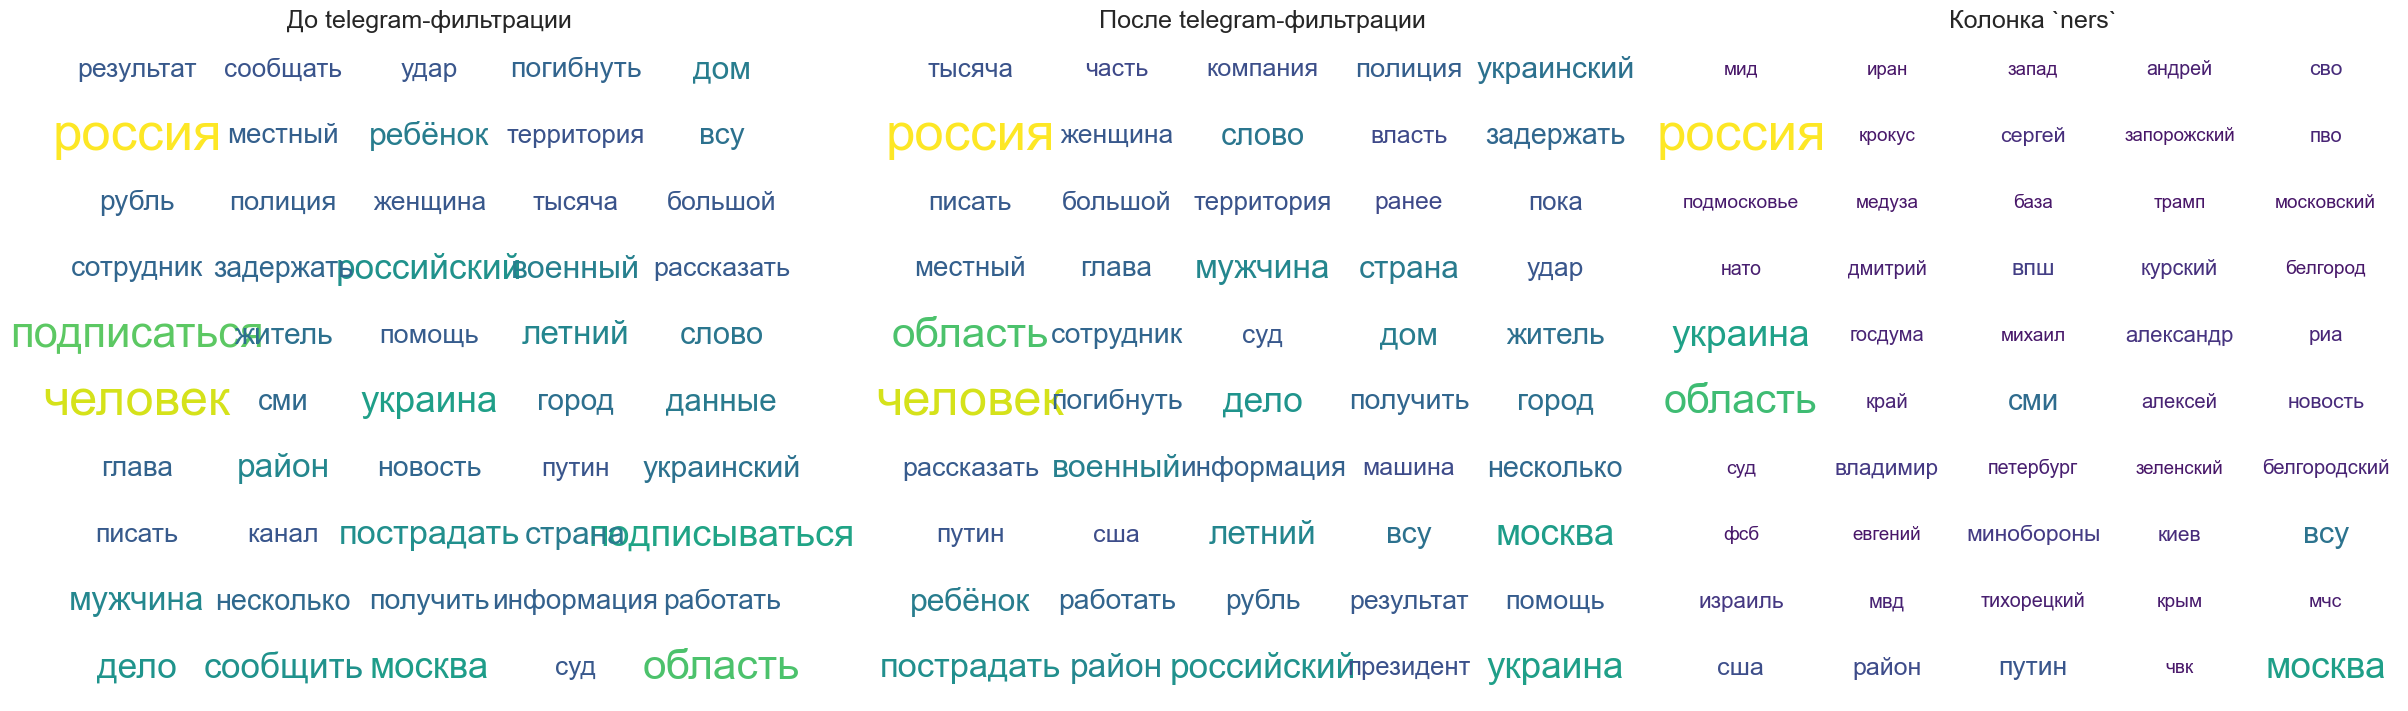

In [108]:


def text_to_counter(series: pd.Series, top_n: int = 80) -> Counter:
    counter = Counter()
    for text in series.fillna(""):
        counter.update(text.split())
    return Counter(dict(counter.most_common(top_n)))


def draw_cloud(ax, frequencies: dict, title: str):
    ax.set_title(title)
    ax.axis("off")
    if not frequencies:
        ax.text(0.5, 0.5, "Нет данных", ha="center", va="center", fontsize=18)
        return

    if HAS_WORDCLOUD:
        cloud = WordCloud(
            width=1000,
            height=600,
            background_color="white",
            colormap="viridis",
            font_path=DEFAULT_FONT,
            random_state=RANDOM_STATE,
        ).generate_from_frequencies(frequencies)
        ax.imshow(cloud, interpolation="bilinear")
        return

    items = sorted(frequencies.items(), key=lambda pair: pair[1], reverse=True)[:50]
    max_freq = max(freq for _, freq in items)
    cols = 5
    rows = int(np.ceil(len(items) / cols))
    coords = [(col, row) for row in range(rows) for col in range(cols)]
    rng = np.random.default_rng(RANDOM_STATE)
    rng.shuffle(coords)
    for (word, freq), (col, row) in zip(items, coords):
        x = (col + 0.5) / cols
        y = 1 - (row + 0.5) / max(rows, 1)
        size = 12 + 26 * (freq / max_freq)
        color = plt.cm.viridis(freq / max_freq)
        ax.text(x, y, word, fontsize=size, color=color, ha="center", va="center", transform=ax.transAxes)


basic_counter = text_to_counter(df["basic_clean_text"])
clean_counter = text_to_counter(df["clean_text"])
ner_counter = text_to_counter(df["ner_lemma_text"])

fig, axes = plt.subplots(1, 3, figsize=(24, 7), constrained_layout=True)
draw_cloud(axes[0], basic_counter, "До telegram-фильтрации")
draw_cloud(axes[1], clean_counter, "После telegram-фильтрации")
draw_cloud(axes[2], ner_counter, "Колонка `ners`")
plt.show()



## Тематическое моделирование

Основной вариант:
- `TfidfVectorizer(ngram_range=(1, 2), max_features=5000)`;
- перебор `k` в диапазоне `5..10`;
- оценка по `inertia` и `silhouette score`;
- финальная модель `KMeans`.


In [109]:

vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=5000, min_df=10, max_df=0.35, sublinear_tf=True)
X_tfidf = vectorizer.fit_transform(df["clean_text"])
feature_names = vectorizer.get_feature_names_out()

print("Размер матрицы TF-IDF:", X_tfidf.shape)

MODEL_SAMPLE_SIZE = 20000
k_values = list(range(5, 11))

if X_tfidf.shape[0] > MODEL_SAMPLE_SIZE:
    rng = np.random.default_rng(RANDOM_STATE)
    sample_idx = np.sort(rng.choice(X_tfidf.shape[0], size=MODEL_SAMPLE_SIZE, replace=False))
    X_model = X_tfidf[sample_idx]
else:
    X_model = X_tfidf

model_metrics = []
for k in k_values:
    model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    labels = model.fit_predict(X_model)
    inertia = float(model.inertia_)
    silhouette = float(silhouette_score(X_model, labels))
    print(f"k={k}, silhouette={silhouette:.4f}, inertia={inertia:.2f}")
    model_metrics.append({"k": k, "silhouette": silhouette, "inertia": inertia})

model_selection = pd.DataFrame(model_metrics)
optimal_k = int(model_selection.sort_values(["silhouette", "inertia"], ascending=[False, True]).iloc[0]["k"])
model_selection


Размер матрицы TF-IDF: (90973, 5000)
k=5, silhouette=0.0033, inertia=19576.79
k=6, silhouette=0.0032, inertia=19541.30
k=7, silhouette=0.0033, inertia=19509.25
k=8, silhouette=0.0035, inertia=19476.18
k=9, silhouette=0.0040, inertia=19444.93
k=10, silhouette=0.0043, inertia=19415.20


,k,silhouette,inertia
0,5,0.003263,19576.790737
1,6,0.003204,19541.302980
2,7,0.003296,19509.252651
3,8,0.003491,19476.177569
4,9,0.004044,19444.926806
5,10,0.004264,19415.203547


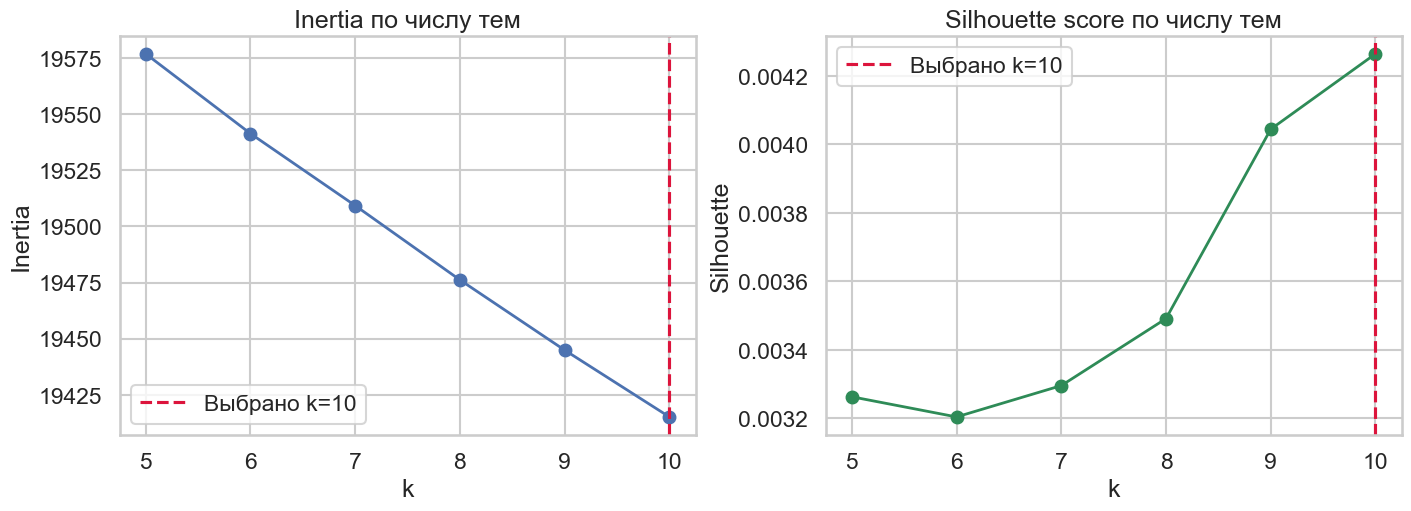

In [110]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

axes[0].plot(model_selection["k"], model_selection["inertia"], marker="o", linewidth=2)
axes[0].axvline(optimal_k, color="crimson", linestyle="--", label=f"Выбрано k={optimal_k}")
axes[0].set_title("Inertia по числу тем")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")
axes[0].legend()

axes[1].plot(model_selection["k"], model_selection["silhouette"], marker="o", linewidth=2, color="#2E8B57")
axes[1].axvline(optimal_k, color="crimson", linestyle="--", label=f"Выбрано k={optimal_k}")
axes[1].set_title("Silhouette score по числу тем")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette")
axes[1].legend()

plt.show()


In [111]:

TOPIC_NAME_EXCLUDE = {"год", "день", "сегодня", "новый", "видео", "место", "время", "работа", "всё", "первый", "хотеть", "заявить", "произойти", "находиться", "появиться"}
GENERIC_TOPIC_WORDS = TOPIC_NAME_EXCLUDE | {"человек", "россия", "российский", "самый", "большой", "хороший", "работать", "страна"}


def topic_label_from_words(words, top_n: int = 3):
    filtered = [word for word in words if word not in TOPIC_NAME_EXCLUDE and " " not in word]
    chosen = filtered[:top_n] if len(filtered) >= top_n else words[:top_n]
    return ", ".join(chosen)


def extract_topic_terms_from_components(components: np.ndarray, features: np.ndarray, n_top_words: int = 10):
    order = components.argsort(axis=1)[:, ::-1]
    topic_terms = {}
    for topic_id in range(components.shape[0]):
        topic_terms[topic_id] = [features[idx] for idx in order[topic_id, :n_top_words]]
    return topic_terms


def print_topic_word_lists(topic_terms: dict, model_name: str):
    print(f"=== {model_name} ===")
    for topic_id in sorted(topic_terms):
        print(f"Topic {topic_id}:")
        for word in topic_terms[topic_id]:
            print(f"- {word}")
        print()


def build_topic_artifacts(base_df: pd.DataFrame, model_name: str, doc_topics: np.ndarray, topic_terms: dict, doc_topic_weights: np.ndarray):
    model_df = base_df.copy()
    model_df["topic"] = doc_topics.astype(int)
    topic_name_map = {topic_id: topic_label_from_words(words, top_n=3) for topic_id, words in topic_terms.items()}
    model_df["topic_name"] = model_df["topic"].map(lambda topic_id: f"Topic {topic_id}: {topic_name_map[topic_id]}")

    topic_examples = []
    for topic_id in sorted(topic_terms):
        topic_docs = model_df.loc[model_df["topic"] == topic_id, ["date", "text", "clean_text"]]
        sample_n = min(5, len(topic_docs))
        sampled = topic_docs.sample(sample_n, random_state=RANDOM_STATE) if sample_n else topic_docs.head(0)
        for rank, (_, row) in enumerate(sampled.iterrows(), start=1):
            topic_examples.append(
                {
                    "model_name": model_name,
                    "topic": topic_id,
                    "topic_name": topic_name_map[topic_id],
                    "example_rank": rank,
                    "date": row["date"],
                    "text": row["text"],
                    "clean_text": row["clean_text"],
                }
            )

    topic_examples_df = pd.DataFrame(topic_examples)
    topic_summary = pd.DataFrame(
        {
            "model_name": model_name,
            "topic": list(topic_terms.keys()),
            "topic_name": [topic_name_map[topic_id] for topic_id in topic_terms],
            "top_words": [", ".join(topic_terms[topic_id]) for topic_id in topic_terms],
            "documents": [int((model_df["topic"] == topic_id).sum()) for topic_id in topic_terms],
            "sample_texts": [
                " || ".join(topic_examples_df.loc[topic_examples_df["topic"] == topic_id, "text"].head(5).tolist())
                for topic_id in topic_terms
            ],
        }
    ).sort_values("documents", ascending=False).reset_index(drop=True)

    return {
        "model_name": model_name,
        "df": model_df,
        "doc_topics": doc_topics,
        "doc_topic_weights": doc_topic_weights,
        "topic_terms": topic_terms,
        "topic_name_map": topic_name_map,
        "topic_examples_df": topic_examples_df,
        "topic_summary": topic_summary,
    }


def mean_top_word_overlap(topic_terms: dict, top_n: int = 10) -> float:
    topic_sets = [set(words[:top_n]) for words in topic_terms.values()]
    overlaps = []
    for idx, left in enumerate(topic_sets):
        for right in topic_sets[idx + 1:]:
            overlaps.append(len(left & right) / max(len(left | right), 1))
    return float(np.mean(overlaps)) if overlaps else 0.0


def unique_top_words_share(topic_terms: dict, top_n: int = 10) -> float:
    all_words = [word for words in topic_terms.values() for word in words[:top_n]]
    return len(set(all_words)) / max(len(all_words), 1)


def generic_topic_share(topic_terms: dict, top_n: int = 10) -> float:
    all_words = [word for words in topic_terms.values() for word in words[:top_n]]
    generic_count = sum(word in GENERIC_TOPIC_WORDS for word in all_words)
    return generic_count / max(len(all_words), 1)


def compute_topic_model_score(artifact: dict) -> dict:
    summary = artifact["topic_summary"]
    doc_topic_weights = artifact["doc_topic_weights"]
    counts = summary["documents"].to_numpy()
    largest_topic_share = counts.max() / counts.sum()
    size_cv = float(np.std(counts) / max(np.mean(counts), 1e-9))
    focus = float(np.mean(doc_topic_weights.max(axis=1)))
    overlap = mean_top_word_overlap(artifact["topic_terms"], top_n=10)
    uniqueness = unique_top_words_share(artifact["topic_terms"], top_n=10)
    generic_share = generic_topic_share(artifact["topic_terms"], top_n=10)
    score = focus + uniqueness - largest_topic_share - overlap - 0.25 * size_cv - 0.5 * generic_share
    return {
        "model_name": artifact["model_name"],
        "score": round(score, 4),
        "largest_topic_share": round(largest_topic_share, 4),
        "size_cv": round(size_cv, 4),
        "mean_doc_focus": round(focus, 4),
        "top_word_overlap": round(overlap, 4),
        "unique_top_words_share": round(uniqueness, 4),
        "generic_top_words_share": round(generic_share, 4),
    }


kmeans = KMeans(n_clusters=optimal_k, random_state=RANDOM_STATE, n_init=20)
kmeans_doc_topics = kmeans.fit_predict(X_tfidf)
kmeans_topic_terms = extract_topic_terms_from_components(kmeans.cluster_centers_, feature_names, n_top_words=10)
print_topic_word_lists(kmeans_topic_terms, model_name="KMeans")

kmeans_distances = kmeans.transform(X_tfidf)
kmeans_similarities = 1 / np.maximum(kmeans_distances, 1e-9)
kmeans_weights = kmeans_similarities / kmeans_similarities.sum(axis=1, keepdims=True)

topic_artifacts = {
    "KMeans": build_topic_artifacts(df, "KMeans", kmeans_doc_topics, kmeans_topic_terms, kmeans_weights)
}


=== KMeans ===
Topic 0:
- мужчина
- летний
- полиция
- задержать
- женщина
- ребёнок
- девушка
- сотрудник
- больница
- полицейский

Topic 1:
- противник
- направление
- всу
- запорожский
- бой
- пункт
- позиция
- войско
- враг
- запорожский направление

Topic 2:
- дело
- уголовный
- уголовный дело
- суд
- возбудить
- возбудить уголовный
- статья
- задержать
- следствие
- арестовать

Topic 3:
- самолёт
- аэропорт
- борт
- рейс
- пассажир
- посадка
- пилот
- крушение
- экипаж
- внуково

Topic 4:
- область
- курский
- беспилотник
- курский область
- губернатор
- белгородский
- пво
- бпнуть
- сбить
- украинский

Topic 5:
- россия
- человек
- рубль
- российский
- самый
- большой
- компания
- работать
- тысяча
- хороший

Topic 6:
- пострадать
- человек
- пожар
- погибнуть
- взрыв
- дом
- результат
- мчс
- человек погибнуть
- здание

Topic 7:
- израиль
- израильский
- хамас
- сектор газ
- сектор
- газ
- иран
- цахать
- удар
- хезболл

Topic 8:
- москва
- ожидаться
- центр
- дождь
- температу

In [112]:

kmeans_topic_summary = topic_artifacts["KMeans"]["topic_summary"]
kmeans_topic_examples = topic_artifacts["KMeans"]["topic_examples_df"]

kmeans_topic_summary


,model_name,topic,topic_name,top_words,documents,sample_texts
0,KMeans,5,"россия, человек, рубль","россия, человек, рубль, российский, самый, большой, компания, работать, тысяча, хороший",41202,"Порой кажется, что мы в своем познании настолько преисполнились, что россиян уже ничем не удивить. Но новостям из регионов удается это с..."
1,KMeans,9,"украина, путин, россия","украина, путин, россия, президент, страна, сша, российский, военный, владимир, зеленский",10656,"Заявления Зампреда Совбеза РФ Медведев:\n▪️\nЗападные противники решили реально разгромить крупнейшую ядерную державу - Россию,\nони без..."
2,KMeans,0,"мужчина, летний, полиция","мужчина, летний, полиция, задержать, женщина, ребёнок, девушка, сотрудник, больница, полицейский",10154,"В Свердловской области мать спасла дочку от насильника.\nШкольница после прогулки вечером зашла в лифт, а следом за ней – незнакомец. Ка..."
3,KMeans,6,"пострадать, человек, пожар","пострадать, человек, пожар, погибнуть, взрыв, дом, результат, мчс, человек погибнуть, здание",6605,"«Я понимаю, что новости про ситуацию с нашим зданием у многих вызывают много вопросов и переживаний».\nСотрудников Минэкономразвития не ..."
4,KMeans,2,"дело, уголовный, суд","дело, уголовный, уголовный дело, суд, возбудить, возбудить уголовный, статья, задержать, следствие, арестовать",5355,"ФАС возбудила дело в отношении ВТБ из-за нарушений в рекламе вклада.\nПо мнению ведомства, такие действия могут ввести потребителей в за..."
5,KMeans,4,"область, курский, беспилотник","область, курский, беспилотник, курский область, губернатор, белгородский, пво, бпнуть, сбить, украинский",4775,"""Никто никуда не уедет, люди на месте, мы чувствуем поддержку друг друга — и мы это всё переживём"".\nЭто слова священника из села Попово..."
6,KMeans,8,"москва, ожидаться, центр","москва, ожидаться, центр, дождь, температура, центр москва, столица, градус, москвача, синоптик",4562,"❗️\nРЖД запустили в Москве первый в России беспилотный поезд ""Ласточка"", передает корреспондент РИА Новости. Состав начал перевозить пас..."
7,KMeans,1,"противник, направление, всу","противник, направление, всу, запорожский, бой, пункт, позиция, войско, враг, запорожский направление",3799,"Над Авдеевским терриконом коксохима реет русский триколор — долгожданные кадры, подтверждающие наш контроль над ключевой высотой на Авде..."
8,KMeans,3,"самолёт, аэропорт, борт","самолёт, аэропорт, борт, рейс, пассажир, посадка, пилот, крушение, экипаж, внуково",2190,Режим временного ограничения полётов в 11 аэропортов юга и центральной части России продлён до 18 июня — Росавиация.\nПо-прежнему закрыт...
9,KMeans,7,"израиль, израильский, хамас","израиль, израильский, хамас, сектор газ, сектор, газ, иран, цахать, удар, хезболл",1675,"Израильская атака по Ирану ограничилась военными целями,\nа не ядерными или нефтяными объектами\n, утверждает CBS News со ссылкой на ист..."



## NMF Тематическое Моделирование

`NMF` обучается на той же `TF-IDF` матрице и с тем же числом тем, что и `KMeans`. Это позволяет сравнивать модели на одном и том же корпусе без смещения из-за разных признаков или другого `k`.


In [113]:

nmf_model = NMF(n_components=optimal_k, init="nndsvda", random_state=RANDOM_STATE, max_iter=400)
nmf_doc_topic_weights = nmf_model.fit_transform(X_tfidf)
nmf_doc_topics = nmf_doc_topic_weights.argmax(axis=1)
nmf_topic_terms = extract_topic_terms_from_components(nmf_model.components_, feature_names, n_top_words=10)
print_topic_word_lists(nmf_topic_terms, model_name="NMF")

topic_artifacts["NMF"] = build_topic_artifacts(df, "NMF", nmf_doc_topics, nmf_topic_terms, nmf_doc_topic_weights)
nmf_topic_summary = topic_artifacts["NMF"]["topic_summary"]
nmf_topic_examples = topic_artifacts["NMF"]["topic_examples_df"]

nmf_topic_summary


=== NMF ===
Topic 0:
- мужчина
- летний
- ребёнок
- полиция
- женщина
- девушка
- дом
- рассказать
- слово
- больница

Topic 1:
- область
- беспилотник
- курский
- курский область
- губернатор
- пво
- белгородский
- бпнуть
- украинский
- уничтожить

Topic 2:
- россия
- украина
- страна
- российский
- военный
- сша
- война
- украинский
- зеленский
- киев

Topic 3:
- дело
- уголовный
- уголовный дело
- возбудить
- задержать
- суд
- возбудить уголовный
- статья
- дело статья
- следствие

Topic 4:
- противник
- направление
- всу
- запорожский
- бой
- пункт
- позиция
- запорожский направление
- подразделение
- враг

Topic 5:
- москва
- ожидаться
- центр
- москвача
- дождь
- аэропорт
- температура
- рейс
- градус
- центр москва

Topic 6:
- израиль
- удар
- израильский
- хамас
- сектор
- газ
- сектор газ
- ракета
- иран
- атака

Topic 7:
- рубль
- тысяча
- тысяча рубль
- млн
- миллион
- млн рубль
- миллион рубль
- доллар
- цена
- деньга

Topic 8:
- человек
- пострадать
- погибнуть
- пожар
- в

,model_name,topic,topic_name,top_words,documents,sample_texts
0,NMF,2,"россия, украина, страна","россия, украина, страна, российский, военный, сша, война, украинский, зеленский, киев",22530,"Дискуссии об ограничении продажи алкоголя в России не ведется, были различные опыты, которые легко поддаются анализу, сообщил Песков || ..."
1,NMF,0,"мужчина, летний, ребёнок","мужчина, летний, ребёнок, полиция, женщина, девушка, дом, рассказать, слово, больница",13615,"🥰\n«Познакомились в CSGO , поженились 14-ого июня»\n— в кадр Бласта попала пара счастливых молодожён\nсовет да любовь двум геймерам\n❤️ ..."
2,NMF,8,"человек, пострадать, погибнуть","человек, пострадать, погибнуть, пожар, взрыв, результат, дом, данные, человек погибнуть, предварительный",10701,"Депздрав Москвы обновил список пострадавших, госпитализированных в городские больницы. Всего в нём 76 человек.\n🎯\nПодписывайся на SHOT ..."
3,NMF,5,"москва, ожидаться, центр","москва, ожидаться, центр, москвача, дождь, аэропорт, температура, рейс, градус, центр москва",8377,Пожар в Российской госбиблиотеке на улице Воздвиженка в центре Москвы.\nОчаг был на деревянной обшивке крыши. Сейчас огонь на площади пя...
4,NMF,7,"рубль, тысяча, млн","рубль, тысяча, тысяча рубль, млн, миллион, млн рубль, миллион рубль, доллар, цена, деньга",7393,Оборудование и коды маркировки в ходе эксперимента по маркировке сладостей предоставят компаниям бесплатно - чтобы не оказать влияния на...
5,NMF,4,"противник, направление, всу","противник, направление, всу, запорожский, бой, пункт, позиция, запорожский направление, подразделение, враг",7338,"👼\n🪂\nПод Лобковом, Запорожское направление, уничтожили противника вместе с техникой.\nПротивник пытается эвакуировать раненых, трупы и ..."
6,NMF,3,"дело, уголовный, возбудить","дело, уголовный, уголовный дело, возбудить, задержать, суд, возбудить уголовный, статья, дело статья, следствие",6977,Дурова не допрашивали в связи с расследованием по делу о возможном насилии в отношении его ребенка после задержания в Париже — ТАСС со с...
7,NMF,1,"область, беспилотник, курский","область, беспилотник, курский, курский область, губернатор, пво, белгородский, бпнуть, украинский, уничтожить",6878,Российские военные взяли под контроль населенные пункты Успеновка и Борки в Курской области — Минобороны России || Четыре беспилотника у...
8,NMF,9,"путин, президент, владимир","путин, президент, владимир, владимир путин, песок, брикс, кремль, встреча, выборы, переговоры",4463,"За уникальным перелетом на воздушном шаре «ФосАгро», который увенчался новым мировым рекордом, следили сотни тысяч людей по всей России...."
9,NMF,6,"израиль, удар, израильский","израиль, удар, израильский, хамас, сектор, газ, сектор газ, ракета, иран, атака",2701,Израильская армия объявила о ликвидации главы подразделения преветнивной безопасности «Хезболлы» Набиля Каука в результате авиаудара. ||...



## Сравнение KMeans И NMF

Ниже сравниваются две модели на одном и том же датасете. Используются внутренние proxy-метрики качества тем:
- перекос самого большого топика;
- разброс размеров тем;
- сфокусированность распределения документов по темам;
- пересечение топ-слов между темами;
- доля слишком общих слов в топ-словах.

Модель с лучшим суммарным score используется дальше в блоках динамики и прогнозирования.


In [114]:

topic_model_comparison = pd.DataFrame(
    [compute_topic_model_score(topic_artifacts[model_name]) for model_name in ["KMeans", "NMF"]]
).sort_values("score", ascending=False).reset_index(drop=True)

comparison_preview = pd.concat(
    [
        topic_artifacts[model_name]["topic_summary"].assign(topic_model=model_name).head(5)
        for model_name in ["KMeans", "NMF"]
    ],
    ignore_index=True,
)

SELECTED_TOPIC_MODEL = topic_model_comparison.iloc[0]["model_name"]
selected_artifacts = topic_artifacts[SELECTED_TOPIC_MODEL]

df = selected_artifacts["df"].copy()
topic_terms = selected_artifacts["topic_terms"]
topic_name_map = selected_artifacts["topic_name_map"]
topic_examples_df = selected_artifacts["topic_examples_df"].copy()
topic_summary = selected_artifacts["topic_summary"].copy()
topic_summary["topic_model"] = SELECTED_TOPIC_MODEL

print(f"Выбрана модель тем: {SELECTED_TOPIC_MODEL}")
display(topic_model_comparison)
display(comparison_preview[["topic_model", "topic", "topic_name", "documents", "top_words"]])


Выбрана модель тем: NMF


,model_name,score,largest_topic_share,size_cv,mean_doc_focus,top_word_overlap,unique_top_words_share,generic_top_words_share
0,NMF,0.5946,0.2477,0.5835,0.0305,0.0023,0.98,0.04
1,KMeans,0.2461,0.4529,1.2164,0.1029,0.0048,0.96,0.11


,topic_model,topic,topic_name,documents,top_words
0,KMeans,5,"россия, человек, рубль",41202,"россия, человек, рубль, российский, самый, большой, компания, работать, тысяча, хороший"
1,KMeans,9,"украина, путин, россия",10656,"украина, путин, россия, президент, страна, сша, российский, военный, владимир, зеленский"
2,KMeans,0,"мужчина, летний, полиция",10154,"мужчина, летний, полиция, задержать, женщина, ребёнок, девушка, сотрудник, больница, полицейский"
3,KMeans,6,"пострадать, человек, пожар",6605,"пострадать, человек, пожар, погибнуть, взрыв, дом, результат, мчс, человек погибнуть, здание"
4,KMeans,2,"дело, уголовный, суд",5355,"дело, уголовный, уголовный дело, суд, возбудить, возбудить уголовный, статья, задержать, следствие, арестовать"
5,NMF,2,"россия, украина, страна",22530,"россия, украина, страна, российский, военный, сша, война, украинский, зеленский, киев"
6,NMF,0,"мужчина, летний, ребёнок",13615,"мужчина, летний, ребёнок, полиция, женщина, девушка, дом, рассказать, слово, больница"
7,NMF,8,"человек, пострадать, погибнуть",10701,"человек, пострадать, погибнуть, пожар, взрыв, результат, дом, данные, человек погибнуть, предварительный"
8,NMF,5,"москва, ожидаться, центр",8377,"москва, ожидаться, центр, москвача, дождь, аэропорт, температура, рейс, градус, центр москва"
9,NMF,7,"рубль, тысяча, млн",7393,"рубль, тысяча, тысяча рубль, млн, миллион, млн рубль, миллион рубль, доллар, цена, деньга"



## Optional: LDA для сравнения

Это дополнительный блок для грубого сравнения с кластеризацией `KMeans`. `Coherence` считается только если в окружении доступен `gensim`; иначе выводится уведомление.


In [115]:

try:
    from gensim.corpora import Dictionary
    from gensim.models import CoherenceModel
    HAS_GENSIM = True
except ImportError:
    Dictionary = None
    CoherenceModel = None
    HAS_GENSIM = False

lda_vectorizer = CountVectorizer(ngram_range=(1, 2), max_features=3000)
X_lda = lda_vectorizer.fit_transform(df["clean_text"])
lda_model = LatentDirichletAllocation(n_components=optimal_k, random_state=RANDOM_STATE, learning_method="batch")
lda_model.fit(X_lda)
lda_feature_names = lda_vectorizer.get_feature_names_out()

lda_topics = {}
for topic_id, topic_weights in enumerate(lda_model.components_):
    top_indices = topic_weights.argsort()[::-1][:10]
    lda_topics[topic_id] = [lda_feature_names[idx] for idx in top_indices]

if HAS_GENSIM:
    tokenized_docs = [text.split() for text in df["clean_text"].head(50000)]
    dictionary = Dictionary(tokenized_docs)
    coherence_model = CoherenceModel(
        topics=[lda_topics[topic_id] for topic_id in sorted(lda_topics)],
        texts=tokenized_docs,
        dictionary=dictionary,
        coherence="c_v",
    )
    lda_coherence = coherence_model.get_coherence()
    print(f"LDA coherence (c_v): {lda_coherence:.4f}")
else:
    lda_coherence = None
    print("gensim не установлен: coherence для LDA пропущен")

pd.DataFrame({
    "topic": list(lda_topics.keys()),
    "top_words": [", ".join(lda_topics[i]) for i in sorted(lda_topics)],
})


gensim не установлен: coherence для LDA пропущен


,topic,top_words
0,0,"рубль, тысяча, компания, деньга, россия, млн, миллион, банк, цена, тысяча рубль"
1,1,"ребёнок, школа, тихорецкий, район, житель, город, местный, край, семья, вместе"
2,2,"мужчина, летний, женщина, полиция, ребёнок, девушка, дом, больница, слово, москва"
3,3,"россия, российский, запретить, госдума, депутат, закон, крокус, иноагент, организация, информация"
4,4,"всу, область, украинский, направление, противник, военный, курский, район, российский, минобороны"
5,5,"россия, украина, страна, путин, президент, сша, российский, глава, война, министр"
6,6,"человек, самый, большой, хороший, жизнь, просто, говорить, каждый, проблема, делать"
7,7,"дело, задержать, суд, уголовный, уголовный дело, статья, возбудить, сотрудник, убийство, возбудить уголовный"
8,8,"израиль, удар, город, ракета, москва, атака, житель, военный, израильский, чвк"
9,9,"пострадать, человек, область, погибнуть, пожар, результат, дом, район, взрыв, беспилотник"



## Анализ динамики

Для каждой темы строится временной ряд по дням, затем выполняется проверка непрерывности и добавляется опциональное сглаживание `rolling(window=7).mean()`.


In [116]:

topic_daily = df.groupby(["day", "topic"]).size().unstack(fill_value=0).sort_index()
min_date = topic_daily.index.min()
max_date = topic_daily.index.max()
date_range = pd.date_range(min_date, max_date, freq="D")
topic_daily = topic_daily.reindex(date_range, fill_value=0)
topic_daily.index.name = "day"
topic_daily.columns = [f"topic_{topic_id}" for topic_id in topic_daily.columns]
topic_lookup = {f"topic_{topic_id}": f"Topic {topic_id}: {topic_name_map[topic_id]}" for topic_id in topic_terms}

topic_daily_smoothed = topic_daily.rolling(window=7, min_periods=1).mean()

topic_daily.head()


,topic_0,topic_1,topic_2,topic_3,topic_4,topic_5,topic_6,topic_7,topic_8,topic_9
day,,,,,,,,,,
2020-06-12,1,0,0,0,0,0,0,0,0,0
2020-06-13,6,0,0,0,0,0,0,0,2,0
2020-06-14,1,0,0,0,0,0,0,0,0,1
2020-06-15,9,0,0,2,0,1,0,1,1,0
2020-06-16,2,0,0,1,0,0,0,0,2,0


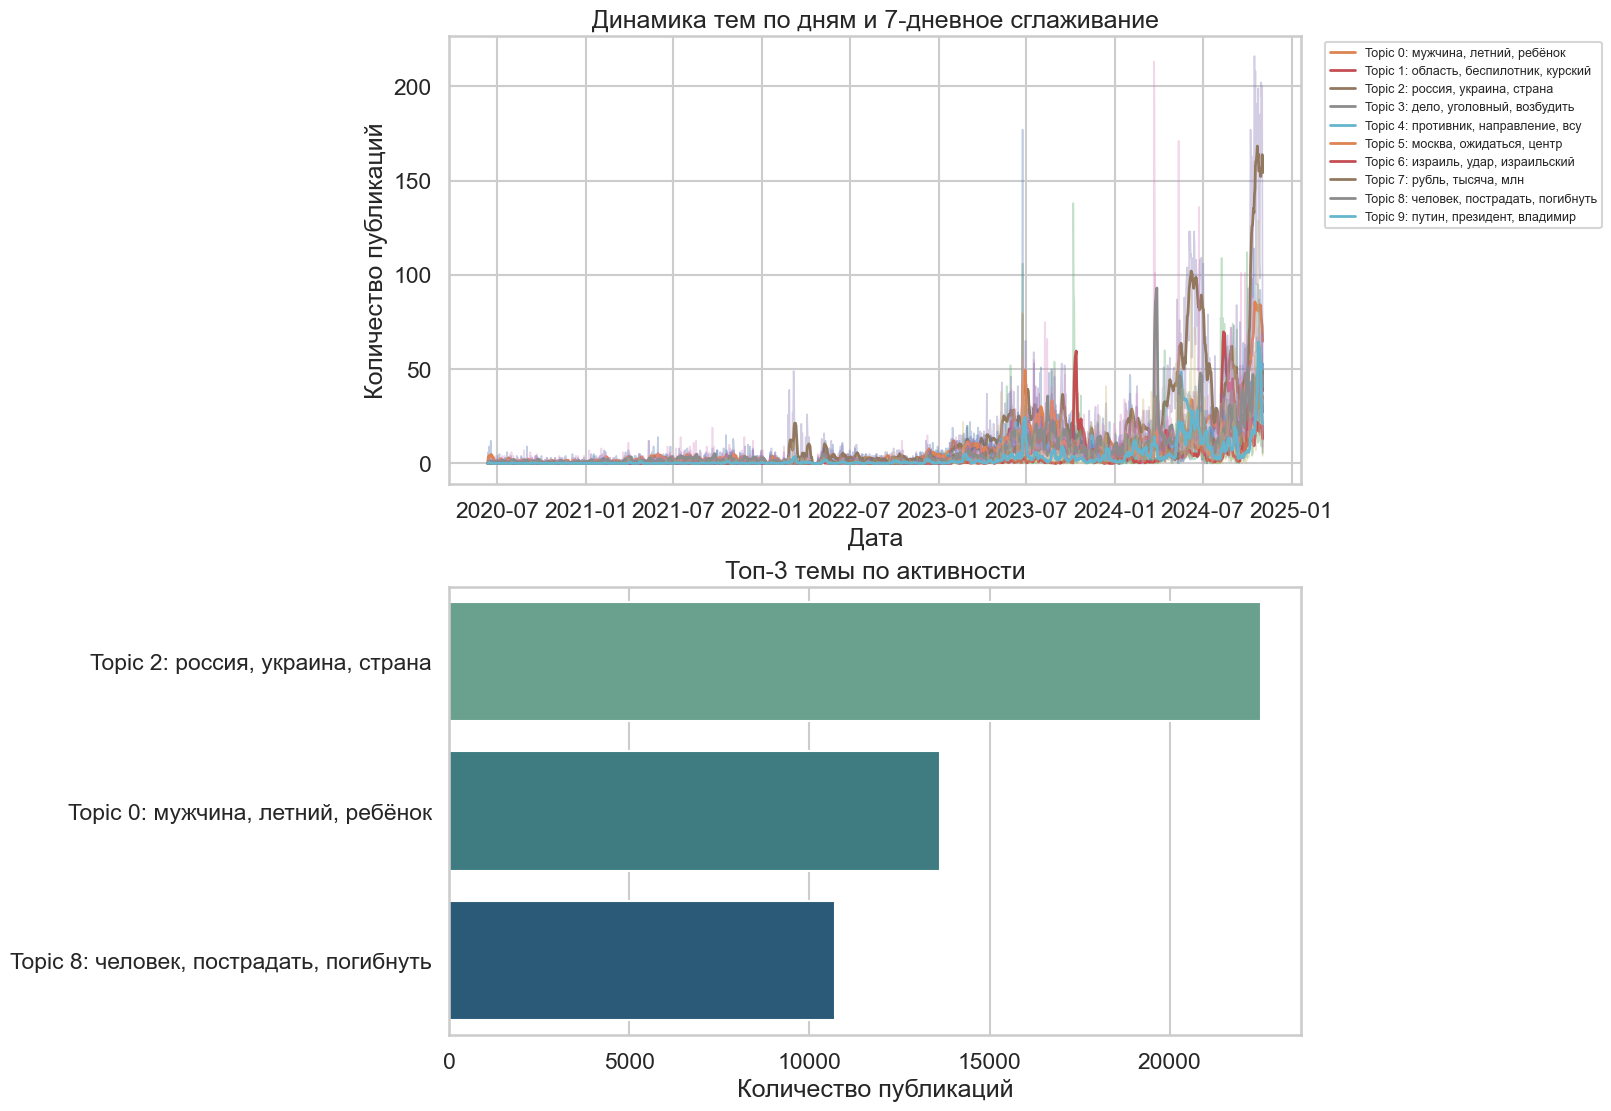

In [117]:

topic_totals = topic_daily.sum().sort_values(ascending=False)
top3_topics = topic_totals.head(3).index.tolist()

fig, axes = plt.subplots(2, 1, figsize=(16, 11), constrained_layout=True)
for col in topic_daily.columns:
    axes[0].plot(topic_daily.index, topic_daily[col], linewidth=1.2, alpha=0.35)
    axes[0].plot(topic_daily_smoothed.index, topic_daily_smoothed[col], linewidth=2, label=topic_lookup[col])
axes[0].set_title("Динамика тем по дням и 7-дневное сглаживание")
axes[0].set_xlabel("Дата")
axes[0].set_ylabel("Количество публикаций")
axes[0].legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), fontsize=9)

bar_data = pd.DataFrame({
    "topic": [topic_lookup[col] for col in top3_topics],
    "posts": topic_totals.loc[top3_topics].values,
})
if HAS_SEABORN:
    sns.barplot(data=bar_data, x="posts", y="topic", ax=axes[1], palette="crest")
else:
    axes[1].barh(bar_data["topic"], bar_data["posts"], color="#4C78A8")
axes[1].set_title("Топ-3 темы по активности")
axes[1].set_xlabel("Количество публикаций")
axes[1].set_ylabel("")

plt.show()



## Детекция событий

Для каждой темы рассчитываются:
- `growth_rate = series.diff()`;
- `event_score = volume + growth_rate`;
- топ-5 пиков по объёму публикаций.


In [118]:

event_rows = []
peak_rows = []
trend_rows = []

for col in topic_daily.columns:
    series = topic_daily[col].astype(float)
    growth_rate = series.diff().fillna(0)
    event_score_series = series + growth_rate
    peaks = series.nlargest(5)

    mean_value = series.mean()
    last_mean = series.tail(14).mean()
    prev_mean = series.iloc[-28:-14].mean() if len(series) >= 28 else series.head(14).mean()
    if last_mean > prev_mean * 1.1:
        trend = "растет"
    elif last_mean < prev_mean * 0.9:
        trend = "падает"
    else:
        trend = "стабилен"

    trend_rows.append(
        {
            "topic": col,
            "topic_name": topic_lookup[col],
            "mean_value": round(mean_value, 3),
            "trend": trend,
            "peak_date": series.idxmax().date(),
            "peak_value": int(series.max()),
        }
    )

    for peak_rank, (peak_date, peak_value) in enumerate(peaks.items(), start=1):
        peak_rows.append(
            {
                "topic": col,
                "topic_name": topic_lookup[col],
                "peak_rank": peak_rank,
                "peak_date": peak_date.date(),
                "peak_value": int(peak_value),
            }
        )

    event_rows.append(
        {
            "topic": col,
            "topic_name": topic_lookup[col],
            "recent_volume": round(series.tail(14).mean(), 3),
            "recent_growth_rate": round(growth_rate.tail(14).mean(), 3),
            "event_score": round(event_score_series.tail(14).mean(), 3),
        }
    )

event_scores = pd.DataFrame(event_rows).sort_values("event_score", ascending=False).reset_index(drop=True)
peak_df = pd.DataFrame(peak_rows)
trend_df = pd.DataFrame(trend_rows)

display(event_scores.head(10))
display(peak_df.head(10))


,topic,topic_name,recent_volume,recent_growth_rate,event_score
0,topic_2,"Topic 2: россия, украина, страна",154.714,-4.643,150.071
1,topic_0,"Topic 0: мужчина, летний, ребёнок",74.286,-2.786,71.500
2,topic_4,"Topic 4: противник, направление, всу",49.071,-2.214,46.857
3,topic_7,"Topic 7: рубль, тысяча, млн",47.000,-1.143,45.857
4,topic_8,"Topic 8: человек, пострадать, погибнуть",44.143,-2.857,41.286
5,topic_9,"Topic 9: путин, президент, владимир",41.357,-0.214,41.143
6,topic_1,"Topic 1: область, беспилотник, курский",38.714,-2.786,35.929
7,topic_3,"Topic 3: дело, уголовный, возбудить",35.643,-0.571,35.071
8,topic_5,"Topic 5: москва, ожидаться, центр",32.714,-0.571,32.143
9,topic_6,"Topic 6: израиль, удар, израильский",16.857,-1.643,15.214


,topic,topic_name,peak_rank,peak_date,peak_value
0,topic_0,"Topic 0: мужчина, летний, ребёнок",1,2024-10-15,114
1,topic_0,"Topic 0: мужчина, летний, ребёнок",2,2024-10-11,98
2,topic_0,"Topic 0: мужчина, летний, ребёнок",3,2024-10-16,97
3,topic_0,"Topic 0: мужчина, летний, ребёнок",4,2024-10-22,95
4,topic_0,"Topic 0: мужчина, летний, ребёнок",5,2024-10-23,95
5,topic_1,"Topic 1: область, беспилотник, курский",1,2024-08-09,109
6,topic_1,"Topic 1: область, беспилотник, курский",2,2023-06-24,106
7,topic_1,"Topic 1: область, беспилотник, курский",3,2024-10-26,87
8,topic_1,"Topic 1: область, беспилотник, курский",4,2024-08-07,77
9,topic_1,"Topic 1: область, беспилотник, курский",5,2024-08-12,77



## Прогнозирование

Сравниваются три модели:
- `Naive baseline`;
- `ARIMA`;
- `Prophet`.

Для каждой темы считается `MAE` и `RMSE` на тестовом интервале `20%`.


In [119]:

TEST_FRACTION = 0.2
MIN_TEST_SIZE = 14
ARIMA_ORDER = (1, 1, 1)


def split_series(series: pd.Series, test_fraction: float = TEST_FRACTION, min_test_size: int = MIN_TEST_SIZE):
    n_test = max(min_test_size, int(len(series) * test_fraction))
    n_test = min(n_test, max(1, len(series) // 3))
    train = series.iloc[:-n_test]
    test = series.iloc[-n_test:]
    return train, test


def compute_metrics(actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    return mae, rmse


def naive_forecast(train: pd.Series, test: pd.Series) -> np.ndarray:
    return np.repeat(train.iloc[-1], len(test))


def arima_forecast(train: pd.Series, horizon: int, order=ARIMA_ORDER) -> np.ndarray:
    if not HAS_STATSMODELS:
        raise ImportError("statsmodels не установлен")
    if train.nunique() <= 1:
        return np.repeat(train.iloc[-1], horizon)
    model = ARIMA(train.astype(float), order=order)
    fitted = model.fit()
    forecast = fitted.forecast(steps=horizon)
    return np.asarray(forecast)


def prophet_forecast(train: pd.Series, horizon: int) -> np.ndarray:
    if not HAS_PROPHET:
        raise ImportError("prophet не установлен")
    prophet_train = train.reset_index()
    prophet_train.columns = ["ds", "y"]
    model = Prophet(daily_seasonality=False, weekly_seasonality=True, yearly_seasonality=True)
    model.fit(prophet_train)
    future = model.make_future_dataframe(periods=horizon, freq="D", include_history=False)
    forecast = model.predict(future)
    return forecast["yhat"].to_numpy()


metrics_rows = []
forecast_store = {}

for col in topic_daily.columns:
    series = topic_daily[col].astype(float)
    if len(series) < 30 or series.sum() == 0:
        continue

    train, test = split_series(series)
    naive_pred = np.clip(naive_forecast(train, test), 0, None)
    naive_mae, naive_rmse = compute_metrics(test, naive_pred)
    metrics_rows.append({"topic": col, "topic_name": topic_lookup[col], "model": "Naive", "MAE": round(naive_mae, 3), "RMSE": round(naive_rmse, 3)})
    forecast_store[(col, "Naive")] = {"train": train, "test": test, "pred": naive_pred}

    try:
        arima_pred = np.clip(arima_forecast(train, len(test)), 0, None)
    except Exception:
        arima_pred = np.repeat(train.iloc[-1], len(test))
    arima_mae, arima_rmse = compute_metrics(test, arima_pred)
    metrics_rows.append({"topic": col, "topic_name": topic_lookup[col], "model": "ARIMA", "MAE": round(arima_mae, 3), "RMSE": round(arima_rmse, 3)})
    forecast_store[(col, "ARIMA")] = {"train": train, "test": test, "pred": arima_pred}

    if HAS_PROPHET:
        try:
            prophet_pred = np.clip(prophet_forecast(train, len(test)), 0, None)
            prophet_mae, prophet_rmse = compute_metrics(test, prophet_pred)
            metrics_rows.append({"topic": col, "topic_name": topic_lookup[col], "model": "Prophet", "MAE": round(prophet_mae, 3), "RMSE": round(prophet_rmse, 3)})
            forecast_store[(col, "Prophet")] = {"train": train, "test": test, "pred": prophet_pred}
        except Exception as exc:
            print(f"Prophet не смог обучиться для {col}: {exc}")

metrics_df = pd.DataFrame(metrics_rows)
comparison_table = metrics_df.pivot_table(index="topic_name", columns="model", values=["MAE", "RMSE"])
comparison_table


17:57:47 - cmdstanpy - INFO - Chain [1] start processing
17:57:47 - cmdstanpy - INFO - Chain [1] done processing
17:57:47 - cmdstanpy - INFO - Chain [1] start processing
17:57:48 - cmdstanpy - INFO - Chain [1] done processing
17:57:48 - cmdstanpy - INFO - Chain [1] start processing
17:57:48 - cmdstanpy - INFO - Chain [1] done processing
17:57:48 - cmdstanpy - INFO - Chain [1] start processing
17:57:48 - cmdstanpy - INFO - Chain [1] done processing
17:57:48 - cmdstanpy - INFO - Chain [1] start processing
17:57:48 - cmdstanpy - INFO - Chain [1] done processing
17:57:49 - cmdstanpy - INFO - Chain [1] start processing
17:57:49 - cmdstanpy - INFO - Chain [1] done processing
17:57:49 - cmdstanpy - INFO - Chain [1] start processing
17:57:49 - cmdstanpy - INFO - Chain [1] done processing
17:57:49 - cmdstanpy - INFO - Chain [1] start processing
17:57:49 - cmdstanpy - INFO - Chain [1] done processing
17:57:49 - cmdstanpy - INFO - Chain [1] start processing
17:57:49 - cmdstanpy - INFO - Chain [1]

MAE                    RMSE  \
model                                     ARIMA   Naive Prophet   ARIMA   
topic_name                                                                
Topic 0: мужчина, летний, ребёнок        14.454  14.632  11.151  23.600   
Topic 1: область, беспилотник, курский   11.965  12.667   9.941  20.290   
Topic 2: россия, украина, страна         39.272  45.542  29.464  58.075   
Topic 3: дело, уголовный, возбудить       9.138  12.717   8.109  14.926   
Topic 4: противник, направление, всу     12.546  13.427  11.075  18.514   
Topic 5: москва, ожидаться, центр         7.493   9.408   7.857  11.546   
Topic 6: израиль, удар, израильский       5.198   5.268   7.375  10.526   
Topic 7: рубль, тысяча, млн               9.978  13.215   7.470  15.466   
Topic 8: человек, пострадать, погибнуть  14.558  17.486  12.941  27.998   
Topic 9: путин, президент, владимир       8.074   8.224   7.617  16.138   

                                                         
model                                     Naive Prophet  
topic_name                                               
Topic 0: мужчина, летний, ребёнок        23.777  18.596  
Topic 1: область, беспилотник, курский   20.960  16.259  
Topic 2: россия, украина, страна         63.171  47.631  
Topic 3: дело, уголовный, возбудить      18.173  12.284  
Topic 4: противник, направление, всу     20.158  15.972  
Topic 5: москва, ожидаться, центр        13.702  10.183  
Topic 6: израиль, удар, израильский      10.582   9.776  
Topic 7: рубль, тысяча, млн              18.247  11.563  
Topic 8: человек, пострадать, погибнуть  30.185  24.446  
Topic 9: путин, президент, владимир      16.481  15.256

In [120]:

for topic_name, topic_metrics in metrics_df.groupby("topic_name"):
    print(topic_name)
    for _, row in topic_metrics.sort_values("model").iterrows():
        print(f"- {row['model']} RMSE: {row['RMSE']:.3f}; MAE: {row['MAE']:.3f}")
    best_row = topic_metrics.sort_values("RMSE").iloc[0]
    print(f"- Лучшая модель: {best_row['model']}")
    print()


Topic 0: мужчина, летний, ребёнок
- ARIMA RMSE: 23.600; MAE: 14.454
- Naive RMSE: 23.777; MAE: 14.632
- Prophet RMSE: 18.596; MAE: 11.151
- Лучшая модель: Prophet

Topic 1: область, беспилотник, курский
- ARIMA RMSE: 20.290; MAE: 11.965
- Naive RMSE: 20.960; MAE: 12.667
- Prophet RMSE: 16.259; MAE: 9.941
- Лучшая модель: Prophet

Topic 2: россия, украина, страна
- ARIMA RMSE: 58.075; MAE: 39.272
- Naive RMSE: 63.171; MAE: 45.542
- Prophet RMSE: 47.631; MAE: 29.464
- Лучшая модель: Prophet

Topic 3: дело, уголовный, возбудить
- ARIMA RMSE: 14.926; MAE: 9.138
- Naive RMSE: 18.173; MAE: 12.717
- Prophet RMSE: 12.284; MAE: 8.109
- Лучшая модель: Prophet

Topic 4: противник, направление, всу
- ARIMA RMSE: 18.514; MAE: 12.546
- Naive RMSE: 20.158; MAE: 13.427
- Prophet RMSE: 15.972; MAE: 11.075
- Лучшая модель: Prophet

Topic 5: москва, ожидаться, центр
- ARIMA RMSE: 11.546; MAE: 7.493
- Naive RMSE: 13.702; MAE: 9.408
- Prophet RMSE: 10.183; MAE: 7.857
- Лучшая модель: Prophet

Topic 6: изра

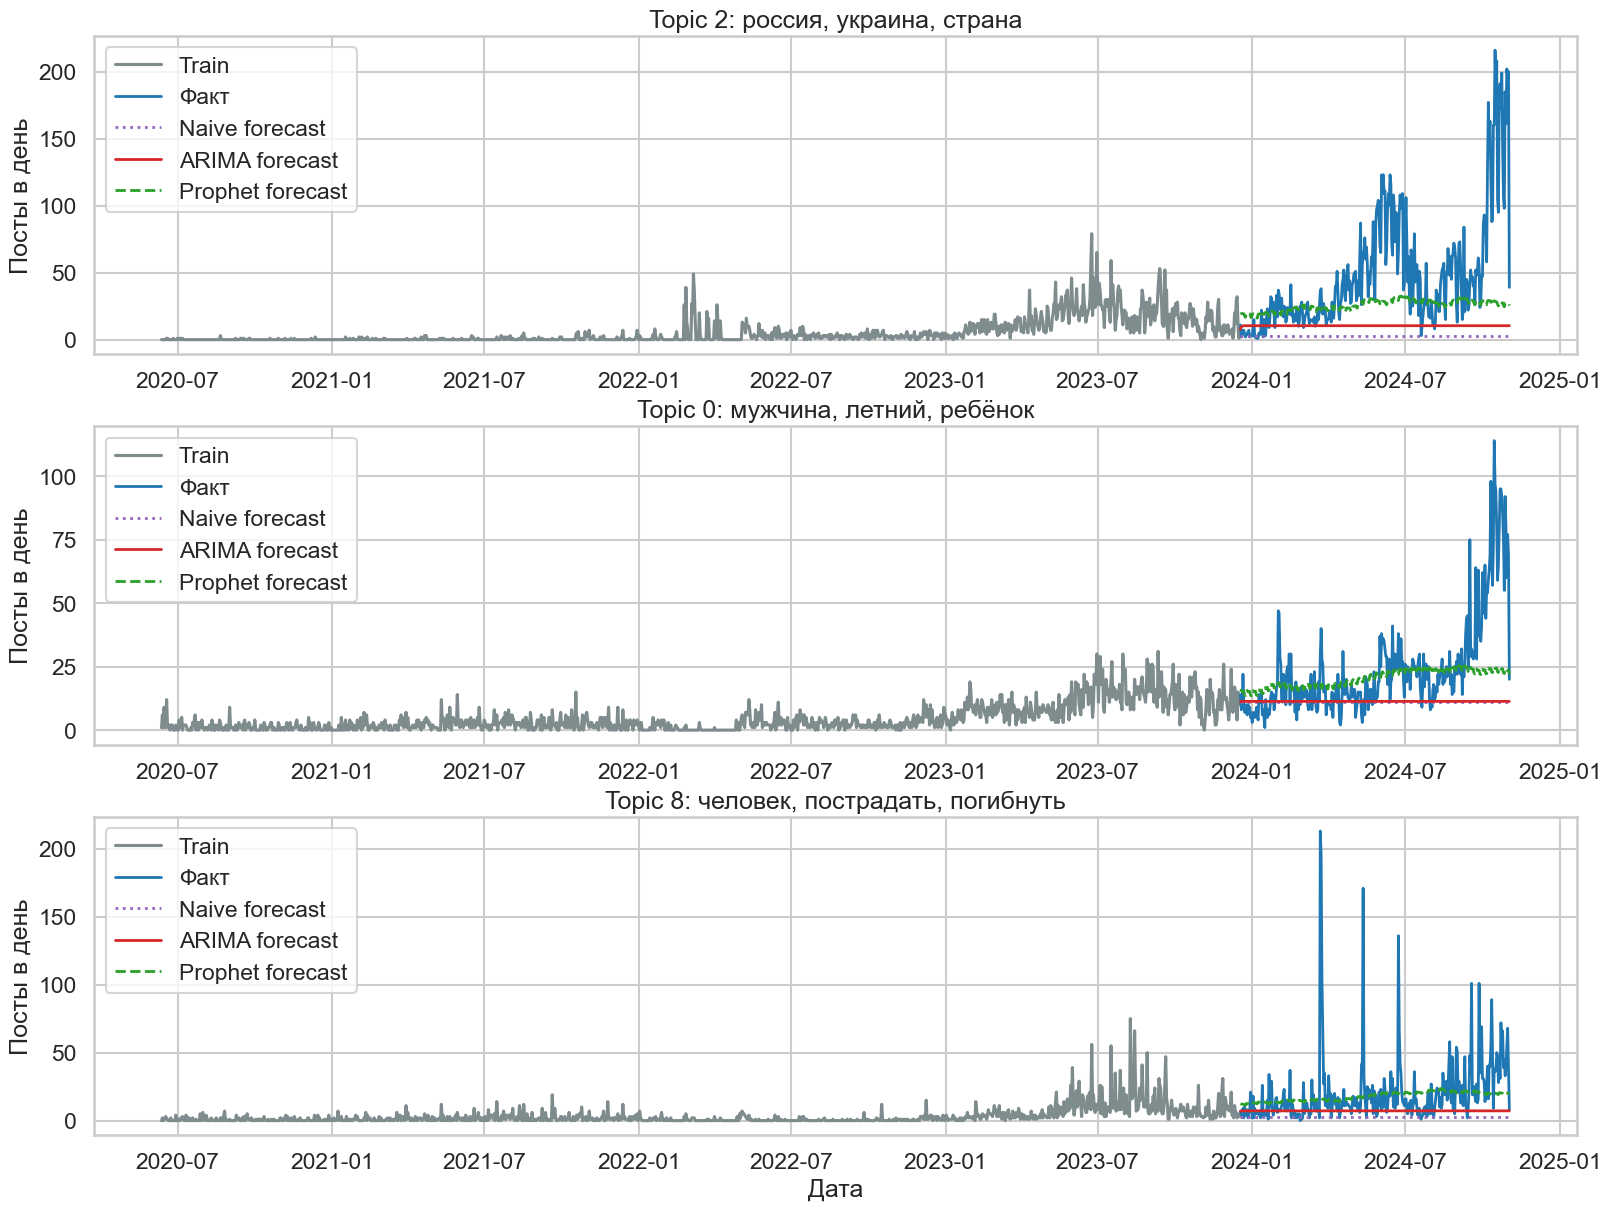

In [121]:

if not metrics_df.empty:
    topics_for_plot = top3_topics
    fig, axes = plt.subplots(len(topics_for_plot), 1, figsize=(16, 4 * len(topics_for_plot)), constrained_layout=True)
    if len(topics_for_plot) == 1:
        axes = [axes]

    for ax, col in zip(axes, topics_for_plot):
        train = forecast_store[(col, "Naive")]["train"]
        test = forecast_store[(col, "Naive")]["test"]
        ax.plot(train.index, train.values, label="Train", color="#7f8c8d")
        ax.plot(test.index, test.values, label="Факт", color="#1f77b4", linewidth=2)
        for model_name, color, style in [("Naive", "#9467bd", ":"), ("ARIMA", "#d62728", "-"), ("Prophet", "#2ca02c", "--")]:
            if (col, model_name) in forecast_store:
                pred = forecast_store[(col, model_name)]["pred"]
                ax.plot(test.index, pred, label=f"{model_name} forecast", color=color, linestyle=style, linewidth=2)
        ax.set_title(topic_lookup[col])
        ax.set_ylabel("Посты в день")
        ax.legend(loc="upper left")
    axes[-1].set_xlabel("Дата")
    plt.show()


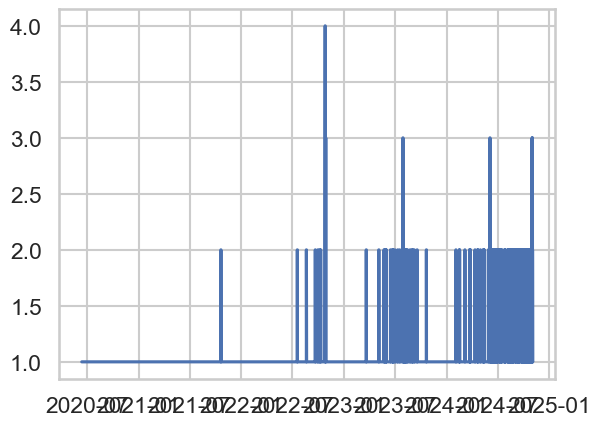

In [127]:
df.groupby('date').size()
plt.plot(df.groupby('date').size())

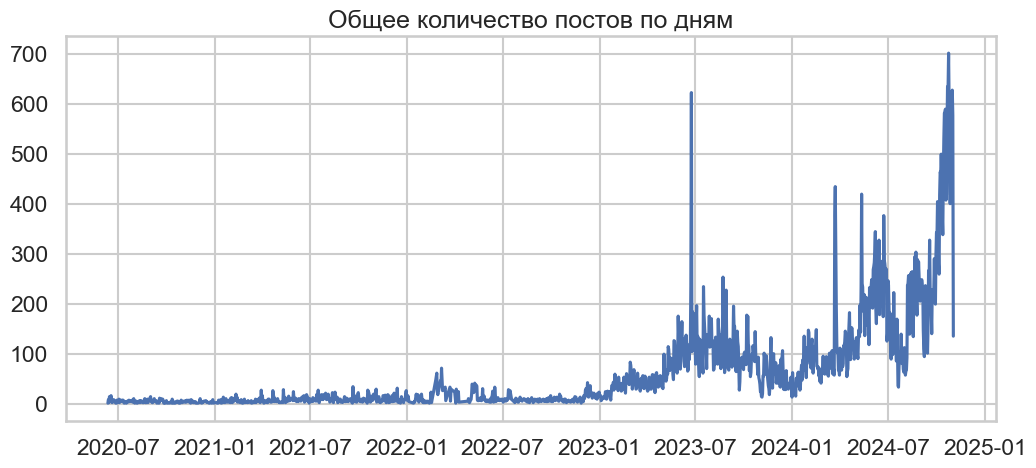

In [130]:
total_daily = df.groupby("day").size()
plt.figure(figsize=(12,5))
plt.plot(total_daily)
plt.title("Общее количество постов по дням")
plt.show()

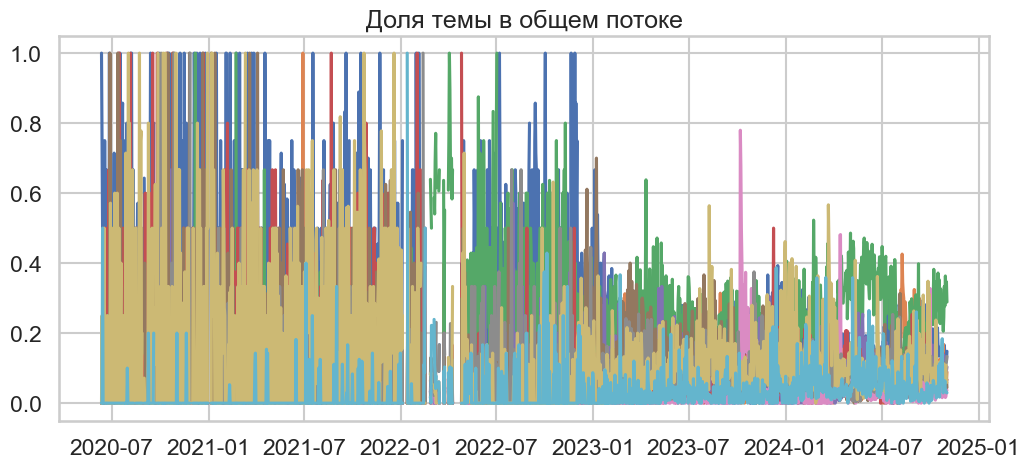

In [131]:
topic_share = topic_daily.div(total_daily, axis=0)
plt.figure(figsize=(12,5))
for col in topic_share.columns:
    plt.plot(topic_share.index, topic_share[col])
plt.title("Доля темы в общем потоке")
plt.show()


## Текстовый отчёт и сохранение результатов

Функция `generate_text_report()` собирает интерпретацию по темам, динамике, событиям, моделям и лидерам по активности. Затем результаты сохраняются в:
- `topics.csv`
- `time_series.csv`
- `metrics.csv`
- `report.txt`


In [122]:

def generate_text_report() -> str:
    lines = []
    lines.append("1. Темы")
    for topic_id in sorted(topic_terms):
        lines.append(f"Topic {topic_id}: {topic_name_map[topic_id]}")

    lines.append("")
    lines.append("2. Динамика")
    for _, row in trend_df.iterrows():
        lines.append(row["topic_name"])
        lines.append(f"- среднее значение: {row['mean_value']:.3f}")
        lines.append(f"- тренд: {row['trend']}")
        lines.append(f"- максимальный пик: {row['peak_date']}, {row['peak_value']}")

    lines.append("")
    lines.append("3. События")
    for topic_name, peak_group in peak_df.groupby("topic_name"):
        lines.append(topic_name)
        for _, row in peak_group.sort_values("peak_rank").iterrows():
            lines.append(f"- пик {int(row['peak_rank'])}: {row['peak_date']}, {row['peak_value']}")

    lines.append("")
    lines.append("4. Модели")
    for topic_name, topic_metrics in metrics_df.groupby("topic_name"):
        lines.append(topic_name)
        for model_name in ["ARIMA", "Prophet", "Naive"]:
            subset = topic_metrics.loc[topic_metrics["model"] == model_name]
            if not subset.empty:
                rmse = subset.iloc[0]["RMSE"]
                mae = subset.iloc[0]["MAE"]
                lines.append(f"- {model_name} RMSE: {rmse:.3f}; MAE: {mae:.3f}")
        best_model = topic_metrics.sort_values("RMSE").iloc[0]["model"]
        lines.append(f"- Лучшая модель: {best_model}")

    lines.append("")
    lines.append("5. ТОП тем")
    lines.append("Топ-3 темы по активности:")
    for rank, topic_col in enumerate(top3_topics, start=1):
        lines.append(f"{rank}. {topic_lookup[topic_col]} — {int(topic_totals[topic_col])} публикаций")

    lines.append("")
    lines.append("6. Качество очистки")
    residual = noise_monitor.loc[(noise_monitor["clean_text"] > 0) | (noise_monitor["ners"] > 0)]
    if residual.empty:
        lines.append("- Контрольные телеграм-маркеры из clean_text удалены полностью.")
    else:
        lines.append("- В clean_text или ners ещё встречаются отдельные телеграм-маркеры:")
        for _, row in residual.iterrows():
            lines.append(f"  {row['term']}: clean_text={row['clean_text']}, ners={row['ners']}")

    return "\n".join(lines)


report_text = generate_text_report()
print(report_text[:4000])


1. Темы
Topic 0: мужчина, летний, ребёнок
Topic 1: область, беспилотник, курский
Topic 2: россия, украина, страна
Topic 3: дело, уголовный, возбудить
Topic 4: противник, направление, всу
Topic 5: москва, ожидаться, центр
Topic 6: израиль, удар, израильский
Topic 7: рубль, тысяча, млн
Topic 8: человек, пострадать, погибнуть
Topic 9: путин, президент, владимир

2. Динамика
Topic 0: мужчина, летний, ребёнок
- среднее значение: 8.483
- тренд: стабилен
- максимальный пик: 2024-10-15, 114
Topic 1: область, беспилотник, курский
- среднее значение: 4.285
- тренд: растет
- максимальный пик: 2024-08-09, 109
Topic 2: россия, украина, страна
- среднее значение: 14.037
- тренд: стабилен
- максимальный пик: 2024-10-16, 216
Topic 3: дело, уголовный, возбудить
- среднее значение: 4.347
- тренд: растет
- максимальный пик: 2024-03-24, 101
Topic 4: противник, направление, всу
- среднее значение: 4.572
- тренд: растет
- максимальный пик: 2023-06-24, 80
Topic 5: москва, ожидаться, центр
- среднее значение:

In [123]:

OUTPUT_DIR = Path(".")

topics_to_save = topic_summary.copy()
time_series_to_save = topic_daily.reset_index().rename(columns={"day": "date"})
metrics_to_save = metrics_df.sort_values(["topic_name", "model"]).reset_index(drop=True)
kmeans_topics_to_save = topic_artifacts["KMeans"]["topic_summary"].copy()
nmf_topics_to_save = topic_artifacts["NMF"]["topic_summary"].copy()

topics_to_save.to_csv(OUTPUT_DIR / "topics.csv", index=False)
time_series_to_save.to_csv(OUTPUT_DIR / "time_series.csv", index=False)
metrics_to_save.to_csv(OUTPUT_DIR / "metrics.csv", index=False)
kmeans_topics_to_save.to_csv(OUTPUT_DIR / "topics_kmeans.csv", index=False)
nmf_topics_to_save.to_csv(OUTPUT_DIR / "topics_nmf.csv", index=False)
topic_model_comparison.to_csv(OUTPUT_DIR / "topic_model_comparison.csv", index=False)
(OUTPUT_DIR / "report.txt").write_text(report_text, encoding="utf-8")

print("Сохранены файлы:")
print("- topics.csv")
print("- time_series.csv")
print("- metrics.csv")
print("- topics_kmeans.csv")
print("- topics_nmf.csv")
print("- topic_model_comparison.csv")
print("- report.txt")


Сохранены файлы:
- topics.csv
- time_series.csv
- metrics.csv
- topics_kmeans.csv
- topics_nmf.csv
- topic_model_comparison.csv
- report.txt
